<a href="https://colab.research.google.com/github/Ananyaramamoolya/edaexample/blob/main/Coffee_Shop_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('Coffee Shop Sales.xlsx', sheet_name='Transactions', header=0)

In [ ]:
print("Dataset info:")
print(df.info())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
 11  Revenue           149116 non-null  float64       
 12  Month             149116 non-null  int64         
 13  Month.1           149116 non-null  object    

In [ ]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
Revenue             0
Month               0
Month.1             0
Weekday             0
Weekday.1           0
Hour                0
dtype: int64


In [ ]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,Month,Month.1,Weekday,Weekday.1,Hour
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,1,Jan,7,Sun,7
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,Jan,7,Sun,7
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,1,Jan,7,Sun,7
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1,Jan,7,Sun,7
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1,Jan,7,Sun,7


In [ ]:
df.tail()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,Month,Month.1,Weekday,Weekday.1,Hour
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,5.00,6,Jun,5,Fri,20
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,6.00,6,Jun,5,Fri,20
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,3.00,6,Jun,5,Fri,20
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,3.75,6,Jun,5,Fri,20
149115,149456,2023-06-30,20:57:19,2,8,Hell's Kitchen,64,0.80,Flavours,Regular syrup,Hazelnut syrup,1.60,6,Jun,5,Fri,20


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.isnull().sum()

,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [ ]:
df.to_csv('Cleaned_Coffee_Sales.csv')

In [ ]:
df['revenue']=df['transaction_qty']*df['unit_price']

In [ ]:
df['month']=df['transaction_date'].dt.month

In [ ]:
df['day']=df['transaction_date'].dt.day_name()

In [ ]:
df['hour']=pd.to_datetime(df['transaction_time'],format='%H:%M:%S').dt.hour

In [ ]:
df['revenue']=df['transaction_qty']*df['unit_price']

In [ ]:
def categorize_hour(hour):
  if hour<12:
    return 'Morning'
  elif hour<17:
    return 'Afternoon'
  else:
    return 'Evening'
df['time_period']=df['hour'].apply(categorize_hour)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
df[['transaction_qty','unit_price','revenue']]=scaler.fit_transform(df[['transaction_qty','unit_price','revenue']])

In [ ]:
df.groupby('product_category')['transaction_qty'].sum().sort_values(ascending=False)

,transaction_qty
product_category,
Coffee,9643.480382
Tea,8052.953319
Drinking Chocolate,1774.812419
Flavours,1373.446603
Packaged Chocolate,-393.433727
Branded,-550.024944
Loose Tea,-977.525276
Coffee beans,-1277.952765
Bakery,-17645.756011


In [ ]:
df.groupby('store_location')['revenue'].sum()

,revenue
store_location,
Astoria,-1154.834503
Hell's Kitchen,-296.106998
Lower Manhattan,1450.941501


In [ ]:
df.groupby('hour')['transaction_id'].count()

,transaction_id
hour,
6,4594
7,13428
8,17654
9,17764
10,18545
11,9766
12,8708
13,8714
14,8933


In [ ]:
df.groupby('day')['revenue'].sum()

,revenue
day,
Friday,-77.087263
Monday,59.197981
Saturday,183.835655
Sunday,-126.160763
Thursday,-168.157292
Tuesday,22.611995
Wednesday,105.759685


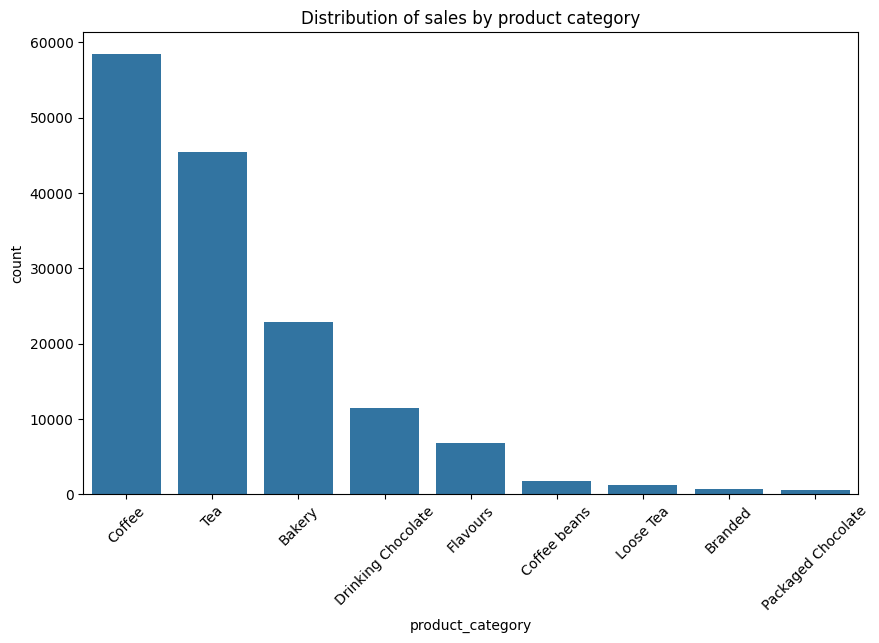

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='product_category',order=df['product_category'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribution of sales by product category')
plt.show()

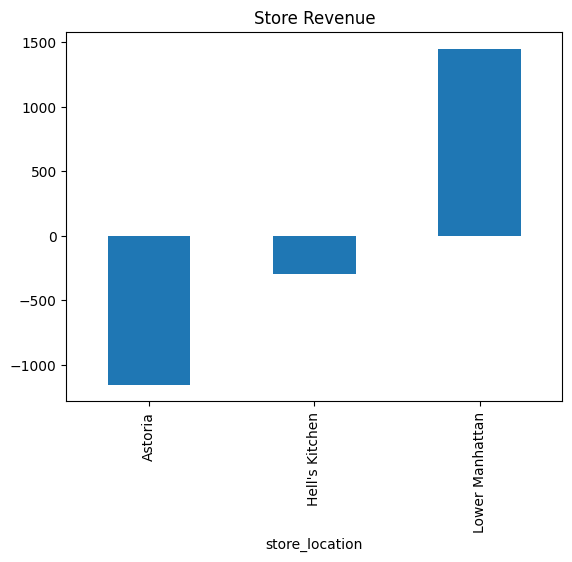

In [ ]:
store_sales=df.groupby('store_location')['revenue'].sum()
store_sales.plot(kind='bar')
plt.title('Store Revenue')
plt.show()

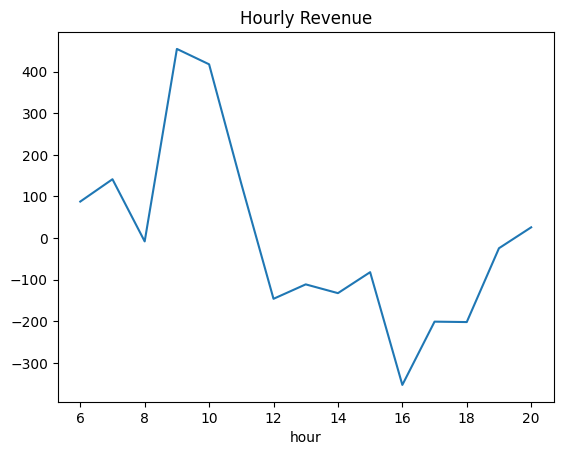

In [ ]:
hourly=df.groupby('hour')['revenue'].sum()
hourly.plot()
plt.title('Hourly Revenue')
plt.show()

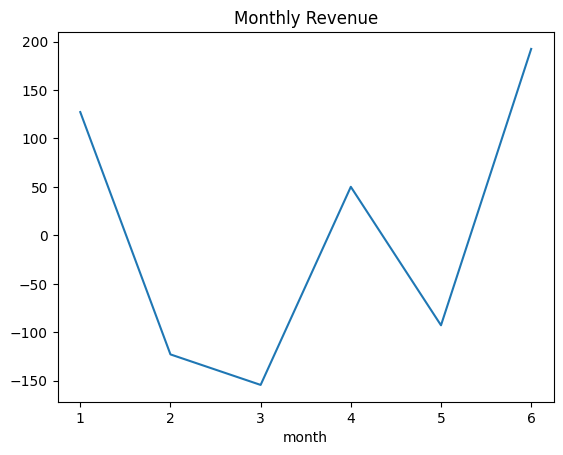

In [ ]:
monthly=df.groupby('month')['revenue'].sum()
monthly.plot(kind='line')
plt.title('Monthly Revenue')
plt.show()

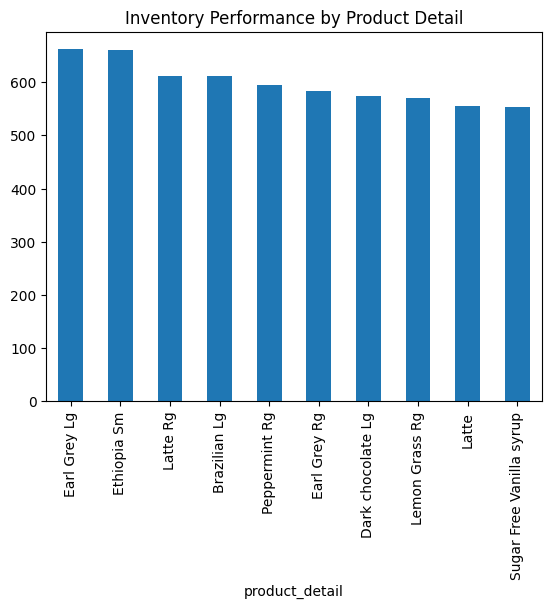

In [ ]:
top_products=df.groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar')
plt.title('Inventory Performance by Product Detail')
plt.show()

In [ ]:
Conclusion:The analysis of the Coffee Shop Sales dataset reveals clear customer purchasing patterns and sales trends.
Coffee-based beverages are the most popular products,contributing significantly to overall revenue.
Sales are highest during peakv morning and afternoon hours,indicating strong demand from working professionals and students.
Certain product categories consistently outperform others,highlighting customer preferences.
The datasets also shows that seasonal and time-based factors influence purchasing behaviour.
Overall,understanding these trends can help the coffee shop optimize inventory ,improve marketing strategies,and enhance customer satisfaction,ultimately leading to increased sales and profitability.

SyntaxError: invalid syntax (3013044095.py, line 1)